</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 2:
        </h2>
        <h1 style="margin-top: -10px;">
            Aprendizaje y selección de modelos de clasificación
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2025-26
                    </p>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #B30033; font-size: 1.5em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1.4em; font-weight: bold">
            Estudiantes
        </h3>
    </div>
    <ul style="list-style-type: none; padding-left: 28px; margin: 0;  font-size: 1.1em">
        <li>Alex Ortega Redondo</li>
        <li>Javier García Meneses</li>
    </ul>

</div>

In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from utils import * 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import xgboost as xgb
from catboost import CatBoostClassifier


## 1. Introducción

El objetivo de esta práctica es construir sobre el trabajo realizado en la Práctica 1. Se aplicarán y compararán diversos modelos de clasificación supervisada, utilizando validación cruzada y ajuste de hiperparámetros, para seleccionar el modelo más eficaz en la predicción del abandono estudiantil.

Para ello, continuaréis utilizando los mismos conjuntos de datos de la práctica anterior (`uclm_student_train.csv` y `uclm_student_test.csv`). El `Pipeline` de preprocesamiento desarrollado en la Práctica 1 servirá como base para el entrenamiento de los modelos (aunque podéis modificarlo).

Tendréis que explorar y evaluar los modelos de clasificación introducidos en el notebook complementario (`Material Práctica 2 - Modelos y Selección.ipynb`), junto con al menos un algoritmo adicional investigado de forma independiente, el cual tendréis que explicar más detalladamente. El rendimiento se evaluará rigurosamente mediante validación cruzada, y técnicas como `GridSearchCV` para encontrar la configuración óptima de hiperparámetros.

El modelo final seleccionado se utilizará para generar predicciones en el conjunto de prueba y participar en la competición de Kaggle.

## 2. Carga de Datos y Preprocesamiento Base




Como punto de partida, cargaremos los datos igual que en la Práctica 1:

In [3]:
pd.set_option('display.max_columns', None)

df_train = pd.read_csv('uclm_student_train.csv')
df_train

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo,abandono
0,TO-2010-GCA531,Graciano Cano Alsina,1992-05-06,Albacete,E1-P02-H04,0,NaN,Científico,6.08,Tiempo completo,60,60,8.16,4.32,~7.2 horas,2,11,1,4,relacion correcto con compañeros,71,43,Azul oscuro,6,GR10335,1
1,CU-2016-MBP239,María Belén Polo,1998-10-31,Cuenca,E2-P03-H06,0,NaN,CIENCIAS PURAS,8.12,Tiempo completo,60,60,9.09,4.05,~11.8 horas,13,2,2,0,Uso normal de la plataforma Moodle,22,38,Coral claro,6,GR13813,0
2,CR-2010-JS201,Judith Sáenz,1992-03-11,Ciudad Real,NaN,0,NaN,Ciencias Puras,10.59,Tiempo completo,60,54,7.99,3.88,~8.8 horas,6,14,2,3,NaN,69,37,Violeta oscuro,6,GR02505,0
3,TO-2016-CDB602,Casandra de Bautista,1998-11-03,Toledo,E1-P04-H18,0,NaN,Humanidades,7.85,Tiempo completo,60,48,7.27,3.81,~8.7 horas,0,0,2,3,Relacion adecuado con compañeros.,3,34,Rosa profundo,6,GR14887,0
4,AB-2011-CAA364,Carlito Alvarado Anaya,1993-12-22,Albacete,NaN,0,NaN,ECONÓMICO,10.23,Tiempo completo,60,60,8.45,4.08,~9.6 horas,16,6,2,3,ha mejorado notablemente en asignaturas troncales,19,39,Coral claro,5,GR09244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40540,AB-2011-CB913,Cecilia Bosch,1993-04-14,Albacete,NaN,0,NaN,CIENCIAS SOCIALES,8.64,Tiempo completo,60,36,5.52,2.94,~1.1h,8,0,3,0,NaN,23,39,Rojo violeta medio,6,GR15949,1
40541,TO-2011-WRL313,Wilfredo Roda Lerma,1987-11-12,Toledo,NaN,1,NaN,Económico,10.59,Tiempo completo,60,60,9.00,4.05,~11.5 horas,8,2,3,2,NaN,76,40,Amarillo,6,GR11547,0
40542,CR-2017-JA946,Javi Acuña,1999-09-05,Ciudad Real,NaN,0,NaN,TECNOLÓGICO,10.41,Tiempo completo,60,54,NaN,3.52,~5.1 horas,3,8,4,4,Expresa dudas sobre continuar los estudios.,24,40,Gris claro,4,GR00625,1
40543,AB-2010-TRM306,Teresita Rodrigo Morera,1992-06-23,Albacete,NaN,0,NaN,Económico,10.15,Tiempo completo,60,54,7.36,3.70,~8.0 horas,10,3,4,0,NaN,39,38,Azul real,6,GR06859,0


Y a partir de aquí reutilizaremos el pipeline de preprocesamiento definido en la Práctica 1. Podéis modificarlo como creáis conveniente, ya que a la hora de trabajar con los modelos podéis seguir descubriendo información de las variables. 

Es fundamental encapsular todas las transformaciones (imputación, escalado, codificación, ingeniería de características) desarrolladas previamente en un único `Pipeline` o `ColumnTransformer` para aplicarlo consistentemente antes de cada modelo.

*Recordatorio: Asegúrate de que tu pipeline de preprocesamiento maneja adecuadamente todos los tipos de variables y artefactos presentes en los datos (`numéricas`, `categóricas`, `fechas`, `texto`, `valores faltantes`, etc.)*.

## 3.-Selección de variables

En la práctica anterior, para hacer la selección de variables utilizamos **Decision Tree**. Para esta práctica, vamos a hacer la selección de las variables con **Random Forest**, ya que hemos visto en clase que ofrece resultados más robustos y estables para medir la importancia de las variables.

Vamos a entrenar un **Random Forest** con todas las variables del dataset, incluidas las que hemos ido creando nosotros (excluyendo los identificadores como `id`, `nombre`, `nacimiento`, `residencia_id`, `grupo_trabajo`, `comentarios`). Tras el entrenamiento, vamos a extraer la importancia asignada a cada variable, y las representaremos mediante una gráfica para identificar cuáles tienen mayor importancia.

In [4]:
def seleccionar_numericas(X):
    return X.select_dtypes(include=np.number).columns

def seleccionar_categoricas(X):
    cat_vars = X.select_dtypes(exclude=np.number).columns
    a_excluir = ['id', 'nombre', 'nacimiento', 'residencia_id', 'grupo_trabajo', 'comentarios']
    cat_vars_filtradas = cat_vars.drop(a_excluir, errors='ignore')
    return cat_vars_filtradas.tolist()

X = df_train.drop(columns=["abandono"])
y = df_train["abandono"]

preproc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), seleccionar_categoricas),
    ('num', StandardScaler(), seleccionar_numericas)
])

RF_pipeline = Pipeline([
    ('limpieza', LimpiezaVariables()),
    ('imputacion_horas', ImputarHorasTrabajo()),
    ('localidad', Localidad()),
    ('genero', Genero()),
    ('edad_entrada', EdadEntrada()),
    ('ratio_creditos', RatioCredito()),
    ('imputacion_nota', ImputarNota()),
    ('participacion', Participacion()),
    ('convocatoria', Convocatoria()),
    ('gp_tbj', GrupoTrabajo()),
    ('nuevas_variables', NuevasVariables()),
    ('comentarios', ImputacionComentarios()),
    ('preproc', preproc),
    ("clf",RandomForestClassifier(random_state=10))  
])

In [5]:
RF_pipeline.fit(X, y)

Pipeline(steps=[('limpieza', LimpiezaVariables()),
                ('imputacion_horas', ImputarHorasTrabajo()),
                ('localidad', Localidad()), ('genero', Genero()),
                ('edad_entrada', EdadEntrada()),
                ('ratio_creditos', RatioCredito()),
                ('imputacion_nota', ImputarNota()),
                ('participacion', Participacion()),
                ('convocatoria', Convocatoria()), ('gp_tbj', GrupoTrabajo()),
                ('nuevas_variables', NuevasVariables()),
                ('comentarios', ImputacionComentarios()),
                ('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  <function seleccionar_categoricas at 0x0000028BBA5804A0>),
                                                 ('num', StandardScaler(),
                                                  <function seleccionar_numericas at 0x0000028BB89FF880>)])),
                ('clf', RandomForestClassifier(random_state=10))])

In [6]:
rf = RF_pipeline.named_steps["clf"]
ct = RF_pipeline.named_steps["preproc"]
feature_names = ct.get_feature_names_out()
importancias = rf.feature_importances_

In [7]:
df_importancias_detalle = pd.DataFrame({
    "feature": feature_names,
    "importance": importancias
}).sort_values("importance", ascending=False)

Al haber utilizado el one-hot para las categóricas, cada valor distinto lo convierte en una variable nueva, por lo que no tenemos la verdadera importancia de las variables categóricas. Por esto, vamos a agruparlas y a sumar sus importancias para obtener la importancia final de esa variable.

In [8]:
variables_originales = [
    'comentario_clasificado',
    'bachillerato',
    'genero',
    'convocatoria',
    'año_entrada',
    'provincia',    
    'domicilio',
    'prov_estudia', 
    'edificio',
    'modalidad',
    'color_fav'
]

def obtener_nombre_agrupado(feature_name):
    if feature_name.startswith('num__'):
        return feature_name.replace('num__', '')
    
    if feature_name.startswith('cat__'):
        nombre_limpio = feature_name.replace('cat__', '')
        for var in variables_originales:
            if nombre_limpio.startswith(var):
                return var
        return nombre_limpio
    
    return feature_name

df_importancias_detalle['feature_agrupada'] = df_importancias_detalle['feature'].apply(obtener_nombre_agrupado)
df_agrupado = df_importancias_detalle.groupby('feature_agrupada')['importance'].sum().reset_index()
df_agrupado = df_agrupado.sort_values('importance', ascending=False)

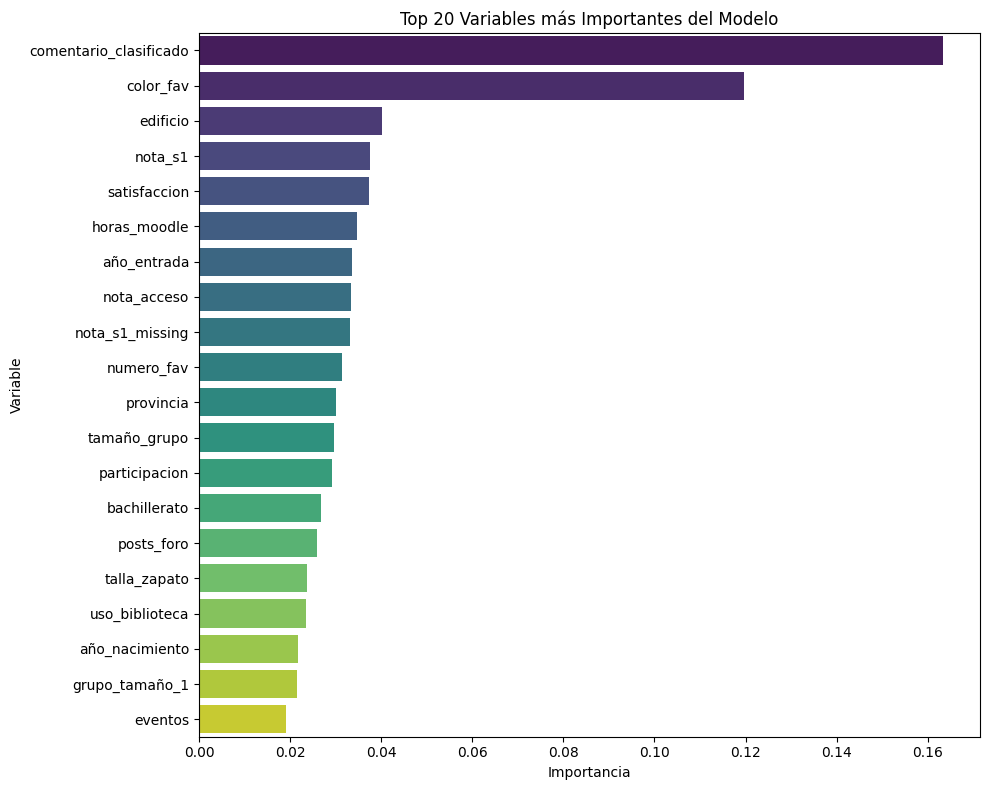

In [9]:
top_n = 20
df_plot = df_agrupado.head(top_n)
plt.figure(figsize=(10, 8))
sns.barplot(data=df_plot, x='importance', y='feature_agrupada', palette='viridis', hue='feature_agrupada', legend=False)
plt.title(f'Top {top_n} Variables más Importantes del Modelo')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

En la gráfica podemos observar como la variable más importante según **Random Forest** es `comentario_clasificado`, la cual tiene mucha importancia con respecto a las demás variables. Con esto podemos ver como la variable `comentarios` va a aportar mucho a la predicción. Le sigue `color_fav`, pero esto puede ser porque **Random Forest** tiende a dar más importancia a variables con muchas categorías distintas, por lo cual no la tendremos en cuenta, ya que consideramos que es ruido. Le siguen variables como `nota_s1`, `satisfaccion`, `nota_s1_missing`, `tamaño_grupo` y `participacion`.

## 4.- Pruebas con modelos

En este apartado vamos a probar diferentes modelos que hemos visto en clase o hemos buscado nosotros. Primero cargamos los datos.

In [10]:
df_train = pd.read_csv('uclm_student_train.csv')

In [11]:
X = df_train.drop(columns=["abandono"])
y = df_train["abandono"]

Primero vamos a instanciar aquí algunas cosas como las variables que vamos a usar para entrenar los modelos, y los preprocesamientos de los Pipelines para así no estar repitiendo código por cada modelo nuevo que vayamos a probar.

Como no vamos a usar las mismas variables para todos los modelos, las hemos dividido según lo que acepte el modelo:
*   **no_tfidf**: Son para los modelos que no aceptan el TF-iDF. En estas variables hemos añadido `comentario_clasificado` y `abandono_binario`.
*   **tdidf_categoricas_numericas**: Son las variables que vamos a usar para la mayoría de los modelos, los comentarios se tratan con TF-iDF.
*   **tfidf_categoricas**: Son para los modelos que solo aceptan variables categóricas. Las variables numéricas las hemos discretizado para poder usarlas.

In [12]:
no_tfidf = {
    'cat_vars': ['bachillerato', 'modalidad', 'prov_estudia', 'genero','domicilio','convocatoria','edificio_prov_estudia','comentario_clasificado'],
    'num_vars': ['nota_acceso','creditos_a1', 'nota_s1', 'satisfaccion','ratio_creditos_superados','participacion','horas_moodle','tamaño_grupo', 'horas_trabajo','edad_entrada'],
    'binarias': ['horas_trabajo_missing', 'nota_s1_missing','mes_matriculado','superados_0', 'abandono_binario']
}
tfidf_categoricas_numericas = {
    'cat_vars': ['bachillerato', 'modalidad', 'prov_estudia', 'genero','domicilio','convocatoria','edificio_prov_estudia'],
    'num_vars': ['nota_acceso','creditos_a1', 'nota_s1', 'satisfaccion','ratio_creditos_superados','participacion','horas_moodle','tamaño_grupo', 'horas_trabajo','edad_entrada'],
    'binarias': ['horas_trabajo_missing', 'nota_s1_missing','mes_matriculado','superados_0'],
}
tfidf_categoricas = {
    'cat_vars': ['horas_trabajo', 'bachillerato', 'modalidad', 'prov_estudia', 'genero','grupo_edad_entrada', 'domicilio', 'nota_acceso_disc', 'categoria_satisfaccion','nota_s1_disc','nivel_participacion','tamaño_grupo','edificio_prov_estudia'],
    'binarias': ['es_local','horas_trabajo_missing', 'nota_s1_missing','mes_matriculado','superados_0','nota_s1_baja','grupo_tamaño_1','horas_trabajo_40'],
}

Para los **Pipelines**, vamos a definir el **text_pipeline** que es el **Pipeline** que aplica la técnica **TF-iDF** a la variable `comentarios`. Vamos a definir los preprocesamientos correspondientes a los tipos de variables que vayamos a usar para entrenar el modelo. Tenemos un preprocesamiento por cada tipo de variable que tenemos. A las variables categóricas le aplicamos **OneHotEncoder**, a las variables numéricas **StandarScaler**, a las variables binarias no les aplicamos nada, y dependiendo de si el modelo acepta **TF-iDF** o no le aplicaremos a la variable `cometarios` esa técnica. Por último, hemos definido un **Pipeline** que nos crea y limpia todas las variables que son comunes para todos los modelos.

In [13]:
text_pipeline = Pipeline([
    ('extract', ExtractComentario()), 
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        max_df=0.9,       
        min_df=5,          
        ngram_range=(1,2)  
    ))
])

#KNN, Gaussiano, Boosting
preproc_no_tfidf = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), no_tfidf['cat_vars']),
    ('num', StandardScaler(), no_tfidf['num_vars']),
    ('bin', 'passthrough', no_tfidf['binarias']),
])

#DecisionTree, Bagging, RandomForest, LogisticRegression, XGBoost, GradientBoosting
preproc_tfidf_cat_num = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), tfidf_categoricas_numericas['cat_vars']),
    ('num', StandardScaler(), tfidf_categoricas_numericas['num_vars']),
    ('bin', 'passthrough', tfidf_categoricas_numericas['binarias']),
    ('txt', text_pipeline, ['comentarios'])
])

#Multinomial, CatBoost, Voting, Stacking
preproc_tfidf_cat = ColumnTransformer([
    ('cat', OneHotEncoder(), tfidf_categoricas['cat_vars']),
    ('bin', 'passthrough', tfidf_categoricas['binarias']),
    ('txt', text_pipeline, ['comentarios'])
])

variables_comunes = Pipeline([
    ('limpieza', LimpiezaVariables()),
    ('imputacion_horas', ImputarHorasTrabajo()),
    ('localidad', Localidad()),
    ('genero', Genero()),
    ('edad_entrada', EdadEntrada()),
    ('ratio_creditos', RatioCredito()),
    ('imputacion_nota', ImputarNota()),
    ('participacion', Participacion()),
    ('convocatoria', Convocatoria()),
    ('gp_tbj', GrupoTrabajo()),
    ('nuevas_variables', NuevasVariables()),
])

Vamos a incializar un DataFrame en el que nos vamos a ir guardando el modelo junto a su f1-score para luego compararlos al final.

In [14]:
resultados_df = pd.DataFrame(columns=['Modelo', 'F1-Score'])

### 4.1 KNeighborsClassifier

**KNeighborsClassifier** es un algoritmo de aprendizaje supervisado de tipo perezoso. No construye una representación interna durante el entrenamiento, sino que almacena las instancias del conjunto de datos para utilizarlas directamente en la fase de inferencia.<br>
Para clasificar una nueva instancia, el algoritmo primero calcula la distancia entre la nueva muestra y las almacenadas, selecciona los k vecinos más cercanos y determina la clase final mediante votación por mayoría simple o ponderada por la inversa de la distancia.

In [15]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [16]:
KNN_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('impuc_cmts', ImputacionComentarios()),
    ('preproc', preproc_no_tfidf),
    ("clf", KNeighborsClassifier())
])

In [17]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(KNN_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'KNN',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.7717 ± 0.0040
f1: 0.4075 ± 0.0067
precision: 0.6163 ± 0.0168
recall: 0.3046 ± 0.0099


Podemos observar como el **accuracy** es alto debido al desbalance del dataset, donde la clase mayoritaria condiciona la mayoría de predicciones. Sin embargo, el **F1-score** es bajo porque el modelo apenas identifica fallos. La **precision** es relativamente buena: cuando predice un fallo suele acertar, aunque lo haga pocas veces. En cambio, el **recall** es muy bajo, ya que KNN rara vez detecta la clase minoritaria al quedar sus vecinos dominados por la clase mayoritaria.

### 4.2 DecisionTreeClassifier

**DecisionTreeClassifier** es un modelo de aprendizaje supervisado no paramétrico que construye una estructura jerárquica de reglas lógicas para dividir recursivamente el espacio de variables. para el entrenamiento, usa una estrategia voraz para realizar particiones binarias. Por cada nodo, selecionna la variable y el umbral que maximizan la homogeneidad de las clases resultantes, minimizando métricas de impureza (Entropía o Índice Gini). Es inestable, ya que pequeños cambios en los datos pueden generar árboles muy distintos, y también es propenso al sobreajuste si no limitamos su crecimiento.

In [18]:
DT_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf", DecisionTreeClassifier(random_state=1, class_weight='balanced', max_depth=10))
])

In [19]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(DT_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Decision Tree',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8376 ± 0.0045
f1: 0.6502 ± 0.0048
precision: 0.7311 ± 0.0041
recall: 0.5854 ± 0.0074


Podemos observar como el **accuracy** aumenta respecto a KNN porque el árbol es capaz de separar mejor patrones incluso con datos desbalanceados. El **F1-score** mejora notablemente, lo que indica que el modelo captura muchos más fallos que antes. La **precision** es alta: cuando el árbol predice un fallo, suele acertar. Sin embargo, lo más destacado es el **recall**, que sube hasta el 58%. Esto es coherente con los Árboles de Decisión, ya que tienden a sobreajustarse a patrones específicos y permiten identificar mejor la clase minoritaria.

### 4.3 Naive-Bayes Multinomial

**Naive Bayes Multinomial** es una variante de los **Naive Bayes**. **Naive Bayes** asume la independencia condicional estricta entre las variables predictoras dada la clase, lo que permite factorizar la probabilidad conjunta como el producto de las probabilidades individuales. Las variables las estima usando Máxima Verosimilitud, que se basa en las frecuencias relativas de las variables. También se le suele aplicar el suavizado de Laplace para evitar probabilidades nulas.<br>
**Naive Bayes Multinomial** modela la distribución condicional de los datos como una distribución multinomial. Funciona muy bien para datos discretos.

In [20]:
NBMultinomial_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", MultinomialNB())
])

In [21]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(NBMultinomial_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Naive Bayes Multinomial',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8653 ± 0.0030
f1: 0.7073 ± 0.0073
precision: 0.8037 ± 0.0067
recall: 0.6315 ± 0.0086


Podemos observar como el **accuracy** es alto y mejora respecto a los modelos anteriores, lo cual refleja que Naive Bayes maneja bien patrones globales incluso con datos desbalanceados. El **F1-score** también aumenta, mostrando que el modelo consigue un equilibrio sólido entre precision y recall. La **precision** es especialmente alta: cuando predice un fallo, casi siempre acierta, lo que es coherente con Naive Bayes al basarse en la probabilidad conjunta. Además, el **recall** es bastante bueno (≈63%), indicando que detecta una proporción amplia de fallos. 

### 4.4 Naive-Bayes Gaussiano

**Naive Bayes Gaussiano** es otra variante de **Naive Bayes** que está diseñada para trabajar con variables numéricas. Asume que la probabilidad de las variables dada una clase sigue una distribución Normal. En lugar de contar frecuencias, **Naive Bayes Gaussiano** estima la media y la desviación típica de cada atributo para cada clase.

In [22]:
NBG_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('impuc_cmts', ImputacionComentarios()),
    ('preproc', preproc_no_tfidf),
    ("clf", GaussianNB())
])

In [23]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(NBG_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Naive Bayes Gaussiano',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8078 ± 0.0070
f1: 0.5094 ± 0.0086
precision: 0.7452 ± 0.0131
recall: 0.3871 ± 0.0079


El **accuracy** se mantiene alto, aunque algo por debajo de otros modelos, lo que refleja que Gaussian NB no captura tan bien la estructura real del dataset. El **F1-score** también es más bajo, señal de que el modelo tiene dificultades para representar correctamente la distribución de la clase minoritaria. La **precision** es elevada: cuando predice un fallo suele acertar, pero lo hace pocas veces. Esto se confirma con el **recall**, que es bajo (≈38%), indicando que detecta pocos fallos reales. En conjunto, estos resultados son esperables, ya que Gaussian NB asume que cada variable sigue una distribución normal y en nuestro caso no es cierto.

### 4.5 Bagging

**Bagging** es un ensemble que mejora la estabilidad y precisión de modelos de aprendizaje automático, reduciendo su varianza y el sobreajuste. Para el entrenamiento, genera múltiples subconjuntos de datos aleatorios mediante muestreo con reemplazo a partir del conjunto original. Sobre cada muestra, entrena un clasificador independiente. Para clasificar una instancia nueva, combina las predicciones de todos los modelos base mediante votación por mayoría.

In [24]:
Bagging_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf",BaggingClassifier(random_state=10))
])

In [25]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(Bagging_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Bagging',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8543 ± 0.0032
f1: 0.6673 ± 0.0080
precision: 0.8110 ± 0.0060
recall: 0.5670 ± 0.0105


El **accuracy** y el **F1-score** aumentan porque el bagging reduce la varianza del modelo al combinar múltiples clasificadores entrenados sobre distintos subconjuntos del dataset. Esto hace que el modelo final sea más estable y generalice mejor que un solo estimador. La **precision** es muy alta, lo que indica que el conjunto de modelos es capaz de aislar patrones fiables para predecir fallos. Además, el **recall** mejora notablemente respecto a modelos más simples, el bagging consigue detectar más casos de la clase minoritaria sin sobreajustarse a ruido puntual. 

Estos resultados son coherentes con el efecto típico del bagging: mayor robustez, menor varianza y mejor equilibrio entre precisión y capacidad de detección.

### 4.6 Random Forest

**Random Forest** es un ensemble que entrena un conjunto de árboles de decisión de forma independiente y semi-estocástica. Mantiene el muestreo de instancias y en cada división del árbol, solo considera un subconjunto aleatorio de variables. Esta restricción hace que los árboles sean distintos entre sí, reduciendo la varianza del modelo global y mitiga el sobreajuste de manera efectiva. La predicción final se obtiene mediante voto por mayoría de todos los árboles.

In [26]:
RF_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf",RandomForestClassifier(random_state=10))  
])

In [27]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(RF_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Random Forest',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8612 ± 0.0033
f1: 0.6700 ± 0.0071
precision: 0.8655 ± 0.0095
recall: 0.5467 ± 0.0108


El **accuracy** es alto y el **F1-score** se mantienen altos porque Random Forest combina muchos árboles diversos, lo que reduce la varianza y evita el sobreajuste típico de un árbol individual. La **precision** es muy elevada: al usar múltiples árboles votando, el modelo identifica patrones consistentes antes de predecir un fallo, lo que aumenta la fiabilidad de las predicciones positivas. El **recall** es algo menor que en bagging, pero sigue siendo bueno, aunque su mecanismo de selección aleatoria de variables puede hacer que sea algo menos sensible a la clase minoritaria. 

Estos resultados encajan bien con el funcionamiento de Random Forest, que busca equilibrio entre robustez, estabilidad y capacidad de generalización.

### 4.7 Logistic Regression

**Regresión Logística** es un modelo lineal generalizado utilizado para tareas de clasificación. Estima la probabilidad de que una instancia pertenezca a una clase determinada. Aplica la función logística a una combinación lineal de las entradas transformando la salida en un valor acotado entre 0 y 1. 

In [28]:
LR_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf",LogisticRegression(random_state=10))  
])

In [29]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(LR_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Regresión Logística',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8630 ± 0.0050
f1: 0.6730 ± 0.0075
precision: 0.8751 ± 0.0098
recall: 0.5468 ± 0.0083


El **accuracy** es alto, lo que refleja que la regresión logística modela bien la frontera entre clases. El **F1-score** es similar al de los mejores modelos previos. La **precision** es muy elevada: la regresión logística solo predice fallo cuando la probabilidad estimada es claramente alta, lo que reduce falsos positivos. En cambio, el **recall** es más moderado, ya que un modelo lineal suele tener dificultades para identificar correctamente todos los patrones no lineales de la clase minoritaria. 

Los resultados tienen sentido: alta fiabilidad en las predicciones positivas, pero menor sensibilidad que modelos más complejos como Random Forest.

### 4.8 Boosting

**Boosting** es un ensemble que transforma un conjunto de clasificadores en un clasificador robusto. Su entremiento es secuencial, los modelos se entrenan uno tras otro, cada nuevo clasificador se enfoca en corregir los errores cometidos por los anteriores. <br>
Asigna un peso a cada instancia del dataset. Tras cada iteración, aumenta el peso de las instancias mal clasificadas y reduce el de las acertadas, haciendo así que el siguiente modelo se centro en los errores. La predicción final es una suma ponderada donde cada clasificador tiene una importancia proporcional a su precisión durante el entrenamiento.

In [30]:
AB_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('comentarios', ImputacionComentarios()),
    ('preproc', preproc_no_tfidf),
    ("clf",AdaBoostClassifier(learning_rate=0.01, random_state=10)) 
])

In [31]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(AB_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'AdaBoost',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8069 ± 0.0047
f1: 0.4265 ± 0.0029
precision: 0.9103 ± 0.0090
recall: 0.2785 ± 0.0028


El **accuracy** se mantiene alto, pero el **F1-score** cae notablemente. Esto tiene sentido porque AdaBoost refuerza iterativamente los ejemplos mal clasificados, lo que lo hace muy sensible al ruido y a clases desbalanceadas. La precision es extremadamente alta: cuando AdaBoost predice un fallo, casi siempre acierta, ya que el modelo se vuelve muy conservador y solo asigna la clase positiva cuando está muy seguro. Sin embargo, el **recall** es muy bajo (≈28%), indicando que casi no detecta fallos reales.

### 4.9 XGboost

**XGBoost** es una implementación avanzada, eficiente y escalable de **Gradient Boosting**. Aunque sigue el principio secuencial de corregir los errores de modelos anteriores, tiene innovaciones algorítmicas y de sistema.<br>
Es un ensemble secuencial, entrena árboles de decisión de forma iterativa, cada nuevo árbol intenta predecir los residuos de las predicciones acumuladas hasta ahora. **XGBoost** tienen algunas mejoras con respecto a **Gradient Boosting**:
*   Su función objetivo incluye términos de regularización L1 y L2 que penalizan la complejidad del modelo, controlando así el overfitting de manera más efectiva.
*   Utiliza una aproximación de Taylor de segundo orden, permitiéndole converger más rápido y preciso hacia el mínimo de la función de coste.
*   Puede manejar los valores perdidos el mismo, no necesita que los imputemos antes.
*   Paraleliza la construcción de cada árbol, reduciendo el tiempo de entrenamiento.

In [32]:
XGB_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf", xgb.XGBClassifier(random_state=10))
])

In [33]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(XGB_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'XGBoost',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8730 ± 0.0035
f1: 0.7138 ± 0.0029
precision: 0.8522 ± 0.0064
recall: 0.6142 ± 0.0072


El **accuracy** es de los más altos obtenidos. El **F1-score** también mejora notablemente: el modelo logra un equilibrio fuerte entre precisión y recuperación. La **precision** es alta, ya que XGBoost construye árboles muy específicos que reducen los falsos positivos. Pero lo más destacable es el **recall** (≈61%), mucho mayor que en AdaBoost y otros modelos: gracias a su regularización, búsqueda exhaustiva de divisiones y manejo del desbalance mediante pesos internos, XGBoost detecta gran parte de los fallos sin sobreajustarse al ruido. 

Estos resultados encajan perfectamente con el comportamiento esperado de XGBoost como uno de los mejores algoritmos para datos tabulares.

### 4.10 Gradient Boosting

**Gradient Boosting** es un ensemble secuencial. Construye el modelo etapa a etapa, cada nuevo modelo base se entrena para predecir los residuos del modelo acumulado hasta ahora. Cada nuevo árbol intenta corregir los errores cometidos por la combinación de árboles anteriores. El modelo final es la suma ponderada de las predicciones de todos los árboles secuenciales.

In [34]:
GBC_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf",GradientBoostingClassifier(random_state=10))
])

In [35]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(GBC_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Gradient Boosting',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8550 ± 0.0041
f1: 0.6353 ± 0.0039
precision: 0.9040 ± 0.0049
recall: 0.4897 ± 0.0046


El **accuracy** es alto, pero el **F1-score** queda por debajo de métodos más potentes como XGBoost o LightGBM. Esto tiene sentido porque Gradient Boosting tradicional construye árboles pequeños y sucesivos que corrigen errores gradualmente, lo que lo vuelve menos flexible ante patrones complejos. La **precision** es muy alta: el modelo solo predice fallo cuando está muy seguro, reduciendo casi por completo los falsos positivos. Sin embargo, el **recall** es más bajo (≈49%), indicando que deja escapar bastantes fallos reales. Este comportamiento es típico del Gradient Boosting original, ya que tiende a ser conservador.

### 4.11 CatBoost

**CatBoost** es una librería de **Gradient Boosting** en árboles de decisión desarrollada por Yandex. Resuelve dos problemas de los algoritmos boosting tradicionales: el manejo de variables categóricas y el sesgo de predicción durante el entrenamiento. La mayoría de algoritmos requieren transformas las variables categóricas en numéricas con **One-Hot**. CatBoost introduce un método llamado **Ordered Target Statistics**. Sustituye cada variable por un valor numérico calculado a partir de las estadísticas de la variable objetivo para esa variable. Para evitar el sobreajuste, no usa la media de todo el dataset, hace una permutación aleatoria de los datos y para cada instancia calcula la estadística basándose en las instancias anteriores en esa permutación. <br>
**CatBoost** entrena modelos separados de manera que el residuo de la instancia **i** se calcula usando un modelo que ha sido entrenando sin la instanci **i**, simulando así un proceso de validación cruzada constante durante el entrenamiento. Construye árboles simétricos, en cada nivel de profundidad del árbol se utiliza la misma condición de división para todos los nodos.

In [36]:
catBoost_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", CatBoostClassifier(verbose=0))
])

In [37]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(catBoost_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'CatBoost',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8729 ± 0.0031
f1: 0.7114 ± 0.0043
precision: 0.8578 ± 0.0029
recall: 0.6078 ± 0.0076


## 5.- GridSearch

El GridSearch es un método exhaustivo para **ajustar hiperparámetros**. Define una **"rejilla"** de valores y prueba sistemáticamente todas sus combinaciones. Usa **validación cruzada** para evaluar cada combinación de forma justa, eligiendo la que mejor generalice para evitar el overfitting. Esto asegura que el modelo va a tener los mejores ajustes para su tarea.

In [38]:
from sklearn.model_selection import GridSearchCV

def optimize_with_grid_search(estimator, param_grid, X_train, y_train, cv_strategy, scoring_metric='accuracy', refit=True, groups=None):
    n_jobs = -1  
    return_train_score = True 

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_metric,
        n_jobs=n_jobs,
        cv=cv_strategy,
        refit=refit, 
        return_train_score=return_train_score,
        verbose=1 
    )

    model_name = type(estimator).__name__
    if isinstance(estimator, Pipeline):
        model_name = type(estimator.steps[-1][1]).__name__

    print(f"--- Iniciando GridSearchCV para {model_name} ---")
    grid_search.fit(X_train, y_train, groups=groups)

    print(f"\nMejores Parámetros encontrados para {model_name}:")
    print(grid_search.best_params_)
    refit_metric_key = refit if isinstance(refit, str) else next(iter(grid_search.scoring)) if isinstance(grid_search.scoring, dict) else 'score'

    results_df = pd.DataFrame(grid_search.cv_results_)
    rank_col_name = f"rank_test_{refit_metric_key}"

    if rank_col_name in results_df.columns:
        results_df = results_df.sort_values(by=rank_col_name)

    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    score_cols = [col for col in results_df.columns if ('mean_test_' in col or 'std_test_' in col or col.startswith('rank_test_'))]
    train_score_cols = [col for col in results_df.columns if ('mean_train_' in col or 'std_train_' in col)]
    time_cols = ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time']

    cols_to_display = param_cols + [col for col in score_cols if col in results_df.columns] + \
                      [col for col in train_score_cols if col in results_df.columns] + \
                      [col for col in time_cols if col in results_df.columns]
   
    cols_to_display = sorted(list(set(cols_to_display)), key=lambda x: (not x.startswith('param_'), x))

    return grid_search

### 5.1 XGboost

In [39]:
param_grid_xgb = {
    'clf__n_estimators': [100, 200],    
    'clf__max_depth': [3, 6, 10],         
    'clf__learning_rate': [0.05, 0.1],    
    'clf__scale_pos_weight': [1, 3]     
}

cv_strategy = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring_metric = 'f1'  

xgb_search_results = optimize_with_grid_search(
    estimator=XGB_pipeline,
    param_grid=param_grid_xgb,
    X_train=X,
    y_train=y,
    cv_strategy=cv_strategy,
    scoring_metric=scoring_metric,
    refit=True, 
    groups=groups
)

best_xgb_model = xgb_search_results.best_estimator_

--- Iniciando GridSearchCV para XGBClassifier ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores Parámetros encontrados para XGBClassifier:
{'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 3}


In [40]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(best_xgb_model,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

Cross-validated scores: 

accuracy: 0.8454 ± 0.0008
f1: 0.7199 ± 0.0056
precision: 0.6751 ± 0.0098
recall: 0.7712 ± 0.0086


Podemos ver, como el modelo que usamos anteriormente sin GrisSearch es un modelo que **sacrificaba el Recall** por tener un Accuracy mayor. Al usar GridSearch, los **hiperparametros** se ajustaron para **priorizar el F1-score**, logrando un notable aumento del Recall y, aunque la Accuracy bajó, el nuevo **resultado fue algo mejor**, elevando el f1-score a 0.7199. Este pequeño aumento demuestra que el modelo es ahora un **predictor más robusto y completo** para la clase de interés.

### 5.2 Regresión Logística

In [41]:
param_grid_logreg = [
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.1, 1.0, 10.0],
        'clf__solver': ['lbfgs']  
    },

    {
        'clf__penalty': ['l1'],
        'clf__C': [0.5, 5.0],        
        'clf__solver': ['liblinear'] 
    }
]

cv_strategy = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring_metric = 'f1'  

lr_search_results = optimize_with_grid_search(
    estimator=LR_pipeline,
    param_grid=param_grid_logreg,
    X_train=X,
    y_train=y,
    cv_strategy=cv_strategy,
    scoring_metric=scoring_metric,
    refit=True, 
    groups=groups
)

best_lr_model = lr_search_results.best_estimator_


--- Iniciando GridSearchCV para LogisticRegression ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Mejores Parámetros encontrados para LogisticRegression:
{'clf__C': 5.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


In [42]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(best_lr_model,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

Cross-validated scores: 

accuracy: 0.8671 ± 0.0047
f1: 0.6890 ± 0.0076
precision: 0.8683 ± 0.0074
recall: 0.5712 ± 0.0101


Podemos observar como el **GridSearch** seleccionó una regularización **Lasso** (L1) con (C=5.0), ya que la configuración por defecto era demasiado estricta. Esto le permitió al modelo subir significativamente el **Recall** al detectar más casos positivos. Aunque la Precisión bajó un poco, el aumento en la detección fue tan importante que subió el **F1-score de 0.6730 0.6890**, logrando un mejor **equilibrio de errores**.

## 6.- Ensembles

Un **ensemble** es un paradigma de aprendizaje automático que, en lugar de buscar un único modelo perfecto, entrena un conjunto de modelos individuales para resolver un mismo problema. Tiene dos fases, en la primera cada miembro procesa los datos y genera su propia predicción, y en la segunda se combinan las salidas mediante una regla de consenso para obtener la predicción final.

### 6.1 Voting Classifier

**Voting Classifier** es un modelo de tipo ensemble heterogéneo. Combina las predicciones de múltiples modelos conceputalmente diferentes entrenados sobre el mismo conjunto de datos. La predicción final se obtiene mediante una regla de agregación:
*   **Hard Voting**: aplica la regla de la mayoría. La clase final es la que recibe más votos de los clasificadores individuales.
*   **Soft Voting**: hace el promedio de las probabilidades de clase predichas por el modelo. Suele ofrecer mejores resultados al capturar la confianza de cada clasificador.

#### 6.1.1 Multinomial y Regresión Logística

In [43]:
nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    voting='soft',  
    n_jobs=-1
)

final_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", voting_clf)
])

In [44]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(final_pipeline,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Voting Classifier Multinomial y Regresión Logística',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8704 ± 0.0032
f1: 0.7108 ± 0.0056
precision: 0.8362 ± 0.0029
recall: 0.6182 ± 0.0083


El **accuracy** es uno de los más altos obtenidos y el **F1-score** también destaca, lo que indica que la combinación de ambos modelos aprovecha sus puntos fuertes. La **precision** se mantiene elevada gracias a la regresión logística, que es muy fiable al predecir la clase positiva. Por otro lado, el **recall** mejora notablemente respecto a usar cada modelo por separado, ya que Naive Bayes contribuye a detectar patrones adicionales que una frontera lineal no captura bien. Este equilibrio tiene sentido: el voting combina la visión probabilística de Naive Bayes con la frontera estable y regularizada de Logistic Regression, reduciendo errores de cada uno y alcanzando un rendimiento más robusto y completo.

### 6.2 Stacking Classifier

**Stacking** es un ensemble heterogéneo y jerárquico, introduce un nivel de aprendizaje adicional para combinar las predicciones:
*   **Nivel 0**: conjunto de modelos diversos que generarn predicciones sobre los datos.
*   **Nivel 1**: un modelo final que usa las predicciones de los modelos del Nivel 0 como variables de entrada.
<br>

El modelo aprende a corregir los sesgos de los modelos base, identificando qué clasificador es más fiable en cada región del espacio de datos. Para evitar el sobreajuste, las predicciones que alimentan al modelo se suelen generar mediante validación cruzada sobre el conjunto de entrenamiento.

#### 6.2.1 Multinomial y Regresión Logística

In [45]:
nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=-1
)

final_pipeline_stack_nblr = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [46]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(final_pipeline_stack_nblr,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Stacking Multinomial y Regresión Logística',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8716 ± 0.0025
f1: 0.7153 ± 0.0056
precision: 0.8343 ± 0.0051
recall: 0.6261 ± 0.0098


#### 6.2.2 XGboost, Multinomial y Regresión Logística

In [47]:
xgb_clf = xgb.XGBClassifier(random_state=42)

nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('xgboost', xgb_clf),
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=-1
)

final_pipeline_stack = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [48]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(final_pipeline_stack,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Stacking XGBoost, Multinomial y Regresión Logística',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8724 ± 0.0047
f1: 0.7177 ± 0.0061
precision: 0.8354 ± 0.0069
recall: 0.6291 ± 0.0091


#### 6.2.3 Catboost, Multinomial y Regresión Logística

In [49]:
cb_clf = CatBoostClassifier(learning_rate=0.1, random_state=42,verbose=0)

nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('catboost', cb_clf),
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=1
)

final_pipeline_stack_cbnblr = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [50]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(final_pipeline_stack_cbnblr,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Stacking CatBoost, Multinomial y Regresión Logística',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8738 ± 0.0033
f1: 0.7207 ± 0.0045
precision: 0.8390 ± 0.0049
recall: 0.6318 ± 0.0092


#### 6.2.4 CatBoost y XGB

In [51]:
cb_clf = CatBoostClassifier(learning_rate=0.1, random_state=42,verbose=0)

xgb_clf = xgb.XGBClassifier(random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('catboost', cb_clf), 
        ('xgboost', xgb_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=1
)

final_pipeline_stack_cbxgb = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [52]:
group_kfold = GroupKFold(n_splits=5)
groups = X['grupo_trabajo']

scoring = ['accuracy', 'f1', 'precision', 'recall']
scores = cross_validate(final_pipeline_stack_cbxgb,X, y,cv=group_kfold,groups=groups,scoring=scoring)
print("Cross-validated scores: \n")
for metric in scoring:
    print(f"{metric}: {scores['test_' + metric].mean():.4f} ± {scores['test_' + metric].std():.4f}")

nueva_fila = pd.DataFrame([{
    'Modelo': 'Stacking CatBoost, XGBoost',
    'F1-Score': scores['test_f1'].mean()
}])

resultados_df = pd.concat([resultados_df, nueva_fila], ignore_index=True)

Cross-validated scores: 

accuracy: 0.8731 ± 0.0037
f1: 0.7196 ± 0.0034
precision: 0.8365 ± 0.0048
recall: 0.6314 ± 0.0068


In [53]:
resultados_df = resultados_df.sort_values(by='F1-Score', ascending=False)
resultados_df

,Modelo,F1-Score
14,"Stacking CatBoost, Multinomial y Regresión Log...",0.720743
15,"Stacking CatBoost, XGBoost",0.719577
13,"Stacking XGBoost, Multinomial y Regresión Logí...",0.717692
12,Stacking Multinomial y Regresión Logística,0.715282
8,XGBoost,0.713805
10,CatBoost,0.711447
11,Voting Classifier Multinomial y Regresión Logí...,0.710837
2,Naive Bayes Multinomial,0.707285
6,Regresión Logística,0.672964
5,Random Forest,0.670022


Como podemos observar en la tabla, los *<u>mejores resultados</u>* en términos de **F1-Score** han sido alcanzados por modelos de **ensemble**, especialmente aquellos que combinan los mejores modelos individuales. Este comportamiento es esperado, ya que los métodos de ensemble buscan **aprovechar las fortalezas de cada modelo**, combinándolos de manera que el rendimiento general se vea mejorado. En particular, combinaciones como **Stacking CatBoost, Multinomial y Regresión Logística** han obtenido los mejores valores, lo que demuestra la efectividad de combinar diferentes enfoques de modelado.

Por otro lado, los *<u>peores resultados</u>* se encuentran con modelos como **KNN y AdaBoost**. Estos modelos **no han logrado adaptarse bien a los datos**, lo cual puede ser una indicación de que los patrones en los datos no son fácilmente capturados por los enfoques que estos algoritmos ofrecen. Este comportamiento marca la **importancia de elegir adecuadamente el modelo** para cada tipo de problema y cómo **ciertos algoritmos pueden no ser los más adecuados para los datos** en cuestión.

## 7.Subidas

In [54]:
df_train = pd.read_csv('uclm_student_train.csv')

In [55]:
X_train = df_train.drop(columns=["abandono"])
y_train = df_train["abandono"]

In [56]:
X_test = pd.read_csv('uclm_student_test.csv')

In [57]:
id_test = X_test[['id']].copy()

### 7.1. XGBoost

In [58]:
XGB_pipeline = Pipeline([
    ('variables', variables_comunes),
    ('preproc', preproc_tfidf_cat_num),
    ("clf", xgb.XGBClassifier(random_state=10))
])

In [59]:
XGB_pipeline.fit(X_train, y_train)
y_pred = XGB_pipeline.predict(X_test)

id_test['abandono'] = y_pred
id_test[['id','abandono']].to_csv('XGBoost.csv',index=False)

Resultado en **Kaggle: 0,7250** vs **Local: 0,7138** 

### 7.2. Stacking con XGBoost, Multinomial y Lostic Regression

In [60]:
xgb_clf = xgb.XGBClassifier(random_state=42)

nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('xgboost', xgb_clf),
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=-1
)

final_pipeline_stack_xgbnblr = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [61]:
final_pipeline_stack_xgbnblr.fit(X_train, y_train)
y_pred = final_pipeline_stack_xgbnblr.predict(X_test)

id_test['abandono'] = y_pred
id_test[['id','abandono']].to_csv('stacking_xgb_nb_lr.csv',index=False)

Resultado en **Kaggle: 0,7304** vs **Local: 0,7197**

### 7.3. Stacking con CatBoost, Multinomial y Regresión Logística

In [62]:
cb_clf = CatBoostClassifier(learning_rate=0.1, random_state=42,verbose=0)

nb_clf = MultinomialNB()

lr_clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('catboost', cb_clf),
        ('naive_bayes', nb_clf), 
        ('log_reg', lr_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=1
)

final_pipeline_stack_cbnblr = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [63]:
final_pipeline_stack_cbnblr.fit(X_train, y_train)
y_pred = final_pipeline_stack_cbnblr.predict(X_test)

id_test['abandono'] = y_pred
id_test[['id','abandono']].to_csv('stacking_cb_nb_lr.csv',index=False)

Resultado en **Kaggle: 0,7326** vs **Local: 0,7194**

### 7.4. Stacking con CatBoost y XGBoost

In [64]:
cat_vars = ['horas_trabajo', 'bachillerato', 'modalidad', 'prov_estudia', 'genero','grupo_edad_entrada', 'domicilio', 'nota_acceso_disc', 'categoria_satisfaccion','nota_s1_disc','nivel_participacion','tamaño_grupo','edificio_prov_estudia']
binarias = ['es_local','horas_trabajo_missing', 'nota_s1_missing','mes_matriculado','superados_0','nota_s1_baja','grupo_tamaño_1','horas_trabajo_40']

In [65]:
cb_clf = CatBoostClassifier(learning_rate=0.1, random_state=42,verbose=0)

xgb_clf = xgb.XGBClassifier(random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('catboost', cb_clf), 
        ('xgboost', xgb_clf)
    ],
    final_estimator=LogisticRegression(),  
    n_jobs=1
)

final_pipeline_stack_cbxgb = Pipeline([
    ('variables', variables_comunes),
    ('disc',Discretizar()),
    ('preproc', preproc_tfidf_cat),
    ("clf", stacking_clf)
])

In [66]:
final_pipeline_stack_cbxgb.fit(X_train, y_train)
y_pred = final_pipeline_stack_cbxgb.predict(X_test)

id_test['abandono'] = y_pred
id_test[['id','abandono']].to_csv('stacking_cbxgb.csv',index=False)

Resultado en **Kaggle: 0,7302 vs Local: 0,7204**

En relación a la comparación entre los resultados obtenidos en Kaggle y los locales, nos gustaría remarcar que los resultados fueron bastante similares, lo que indica que la **validación cruzada** fue muy útil para entender el rendimiento de nuestro modelo antes de enviarlo a la competición.

## 8. Conclusión

La práctica nos ha permitido comprender el **proceso de construcción de modelos de clasificación**, aplicando técnicas avanzadas tanto de **selección de variables** como de **selección y ajuste de modelos**. En primer lugar, se llevó a cabo una **distinción en el preprocesamiento** acorde a las diferentes necesidades de los modelos. Además, hicimos otra **distinción en las variables** que el preprocesamiento iba a utilizar, ya que no todos los modelos aceptaban correctamente las mismas variables. A partir de esta base, la primera fase se centró en analizar la relevancia de las variables mediante métodos como la **importancia de características** en modelos basados en árboles y diferentes aproximaciones. Este análisis nos permitió identificar qué variables aportaban información útil para la tarea de predicción y cuáles podían eliminarse por **redundancia** o baja contribución, favoreciendo modelos más simples.

Posteriormente, se evaluaron distintos **algoritmos de clasificación**: modelos lineales, árboles de decisión, métodos basados en ensembles y modelos basados en gradiente. Para asegurar que cada modelo trabajase en sus condiciones óptimas, se aplicaron técnicas de **búsqueda de hiperparámetros** (como **GridSearch**), junto con **validación cruzada**, permitiendo comparar los clasificadores de manera justa. Este proceso reflejó que el **rendimiento de un modelo puede variar significativamente según su configuración**, teniendo en cuenta el sobreajuste.

Finalmente, se exploraron métodos **ensemble**, que combinan múltiples modelos para **mejorar la robustez y estabilidad de las predicciones**. Estos ensambles, ofrecieron resultados superiores a los modelos individuales, demostrando su capacidad para captar patrones más complejos y reducir la varianza del proceso de aprendizaje. El análisis comparativo evidenció que los mejores desempeños se obtenían precisamente con este tipo de modelos agregados (aunque luego en el score privado perdimos por fiarnos del score público obtenido mediante esta técnica.😢)

En conclusión, la práctica permitió adquirir una **visión completa del ciclo de desarrollo de modelos de clasificación**: desde la comprensión y manipulación de los datos, pasando por la ingeniería de características y la selección de variables, hasta la evaluación rigurosa de modelos y su optimización mediante hiperparámetros. Queremos destacar que la **validación cruzada** jugó un papel fundamental en la predicción del modelo, ya que los resultados obtenidos fueron muy consistentes con los obtenidos localmente, lo que confirma que la validación cruzada es una **excelente técnica para evaluar la efectividad de los modelos**.

El resultado final no es solo un modelo que funciona bien, sino también una forma de trabajar que se puede **aplicar a problemas reales**. Esto demuestra lo importante que es seguir un proceso ordenado y probar las cosas de manera cuidadosa para obtener conclusiones fiables.